In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

/home/ch2343/.conda/envs/single1/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/ch2343/.conda/envs/single1/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
import os
import scanpy as sc
import pandas as pd
import numpy as np

# --------------------------------------------------
# Base directory
# --------------------------------------------------
base_dir = "/nfs/roberts/project/pi_lg689/ch2343/Annotation_challenge_data/immunespace.org/hipc-sc-comp-data/team01/recipe_data"

# --------------------------------------------------
# Infection studies
# Remove infection_study_04 because its var_names are numeric
# Keep study 06 but convert Ensembl IDs -> gene symbols using feature_name
# --------------------------------------------------
study_ids = ["01", "02", "03", "04", "06"]


def standardize_var_names(adata, study_name):
    """
    Standardize feature names across studies.

    Main logic:
    - If var_names are numeric like 0,1,2,..., this dataset is not usable for inner gene merge.
    - If var_names are Ensembl IDs and feature_name exists, use feature_name as gene symbols.
    - If gene_ids exists but var_names are already gene symbols, keep var_names.
    - Remove duplicated gene symbols after conversion.
    """

    var_names = pd.Index(adata.var_names.astype(str))

    # Case 1: numeric var_names, e.g. infection_study_04
    numeric_fraction = var_names.str.fullmatch(r"\d+").mean()
    if numeric_fraction > 0.9:
        raise ValueError(
            f"{study_name}: var_names look numeric, e.g. {list(var_names[:10])}. "
            "This study should probably be removed or fixed from raw feature metadata."
        )

    # Case 2: Ensembl IDs
    ensembl_fraction = var_names.str.startswith("ENSG").mean()

    if ensembl_fraction > 0.5:
        print(f"{study_name}: detected Ensembl-style var_names.")

        if "feature_name" in adata.var.columns:
            print(f"{study_name}: using adata.var['feature_name'] as gene symbols.")

            adata.var["ensembl_id_original"] = adata.var_names.astype(str)
            adata.var_names = adata.var["feature_name"].astype(str)

        elif "gene_symbols" in adata.var.columns:
            print(f"{study_name}: using adata.var['gene_symbols'] as gene symbols.")

            adata.var["ensembl_id_original"] = adata.var_names.astype(str)
            adata.var_names = adata.var["gene_symbols"].astype(str)

        else:
            raise ValueError(
                f"{study_name}: var_names are Ensembl IDs, but no feature_name/gene_symbols column found."
            )

    else:
        print(f"{study_name}: var_names already look like gene symbols.")

    # Clean up possible invalid names
    adata.var_names = adata.var_names.astype(str)
    adata.var_names = adata.var_names.str.strip()

    # Remove empty / nan feature names if any
    valid_features = ~adata.var_names.isin(["", "nan", "None", "NA"])
    if valid_features.sum() < adata.n_vars:
        print(f"{study_name}: removing {adata.n_vars - valid_features.sum()} invalid feature names.")
        adata = adata[:, valid_features].copy()

    # Make gene symbols unique
    adata.var_names_make_unique()

    return adata


adata_list = []
study_keys = []

for sid in study_ids:
    study_name = f"infection_study_{sid}"
    h5ad_path = os.path.join(
        base_dir,
        study_name,
        f"{study_name}_processed.h5ad"
    )

    print("\n" + "=" * 80)
    print(f"Loading: {h5ad_path}")

    if not os.path.exists(h5ad_path):
        print(f"[Warning] File not found, skipping: {h5ad_path}")
        continue

    adata = sc.read_h5ad(h5ad_path)

    print("Before standardization:")
    print(adata)
    print("First 10 var_names:", list(adata.var_names[:10]))
    print("var columns:", list(adata.var.columns))

    # Standardize feature names
    adata = standardize_var_names(adata, study_name)

    print("After standardization:")
    print(adata)
    print("First 10 var_names:", list(adata.var_names[:10]))

    # Make obs names unique across studies
    adata.obs_names = [f"{study_name}_{x}" for x in adata.obs_names.astype(str)]

    # Add study label
    adata.obs["study"] = study_name

    adata_list.append(adata)
    study_keys.append(study_name)


# --------------------------------------------------
# Check shared features before concat
# --------------------------------------------------
feature_sets = {
    study_keys[i]: set(adata_list[i].var_names.astype(str))
    for i in range(len(adata_list))
}

shared_features = set.intersection(*feature_sets.values())

print("\n" + "=" * 80)
print("Number of studies loaded:", len(adata_list))
print("Studies:", study_keys)
print("Shared features across all selected studies:", len(shared_features))
print("Example shared features:", list(shared_features)[:30])


# --------------------------------------------------
# Pairwise feature overlap
# --------------------------------------------------
print("\nPairwise feature overlaps:")
study_names = list(feature_sets.keys())

for i in range(len(study_names)):
    for j in range(i + 1, len(study_names)):
        s1 = study_names[i]
        s2 = study_names[j]
        overlap = feature_sets[s1].intersection(feature_sets[s2])
        print(f"{s1} vs {s2}: {len(overlap)}")


# --------------------------------------------------
# Merge by shared features only
# --------------------------------------------------
adata_merged_infection = sc.concat(
    adata_list,
    join="inner",
    axis=0,
    label="study_concat",
    keys=study_keys,
    index_unique=None
)

print("\n" + "=" * 80)
print("Merged infection AnnData:")
print(adata_merged_infection)
print("Number of studies loaded:", len(adata_list))
print("Studies:", study_keys)
print("Number of shared features:", adata_merged_infection.n_vars)
print("Number of merged cells:", adata_merged_infection.n_obs)
print(adata_merged_infection.obs["study"].value_counts())





Loading: /nfs/roberts/project/pi_lg689/ch2343/Annotation_challenge_data/immunespace.org/hipc-sc-comp-data/team01/recipe_data/infection_study_04/infection_study_04_processed.h5ad
Before standardization:
AnnData object with n_obs × n_vars = 43767 × 26361
    obs: 'sample_id', 'subject_id', 'arm', 'timepoint', 'species', 'tissue', 'age', 'biological_sex', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'Selected', 'sct_detection_rate', 'sct_gmean', 'sct_residual_mean', 'sct_residual_variance', 'sct_variable', 'sct_variance'
First 10 var_names: ['5S-rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A4GALT', 'A4GNT']
var columns: ['Selected', 'sct_detection_rate', 'sct_gmean', 'sct_residual_mean', 'sct_residual_variance', 'sct_variable', 'sct_variance']
infection_study_04: var_names already look like gene symbols.
After standardization:
AnnData object with n_obs × n_vars = 43767 × 26361
    obs: 'sample_id', 'subject_id', 'arm

In [3]:
adata = adata_merged_infection

In [4]:
import scCRAFTplus
from scCRAFTplus.annot import *
from scCRAFTplus.model import *

In [5]:
adata.raw = adata
sc.pp.filter_cells(adata, min_genes=300)
sc.pp.filter_genes(adata, min_cells=5)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)
ranks = rank_genes(adata, markers_PBMC_l3)
start_time = time.time()
process_cell_types_with_ranks(adata, markers_PBMC_l3, ranks)
#perform_permutation_tests(adata, markers_PBMC_l3, ranks)
# End timer
end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time:.2f} seconds")
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='study')
adata = adata[:, adata.var['highly_variable']]

/tmp/ipykernel_499498/1295252089.py:5: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
/home/ch2343/.conda/envs/single1/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


Processed ASDC_mDC
Processed ASDC_pDC
Processed B_intermediate_kappa
Processed B_intermediate_lambda
Processed B_memory_kappa
Processed B_memory_lambda
Processed B_naive_kappa
Processed B_naive_lambda
Processed CD14_Mono
Processed CD16_Mono
Processed CD8_Naive
Processed CD4_Naive
Processed CD4_Proliferating
Processed CD4_TCM_1
Processed CD4_TCM_2
Processed CD4_TCM_3
Processed CD4_TEM_1
Processed CD4_TEM_2
Processed CD4_TEM_3
Processed CD4_TEM_4
Processed CD8_Naive_2
Processed CD8_Proliferating
Processed CD8_TCM_1
Processed CD8_TCM_2
Processed CD8_TCM_3
Processed CD8_TEM_1
Processed CD8_TEM_2
Processed CD8_TEM_3
Processed CD8_TEM_4
Processed CD8_TEM_5
Processed CD8_TEM_6
Processed cDC1
Processed cDC2_1
Processed cDC2_2
Processed dnT_1
Processed dnT_2
Processed Eryth
Processed gdT_1
Processed gdT_2
Processed gdT_3
Processed gdT_4
Processed HSPC
Processed ILC
Processed MAIT
Processed NK_Proliferating
Processed NK_1
Processed NK_2
Processed NK_3
Processed NK_4
Processed NK_CD56bright
Proce

150


Overall Progress:   0%|          | 0/150 [00:00<?, ?it/s]

Training completed in 243.58 seconds
Generating data loader...
Data loader created with 22 batches.


/home/ch2343/.conda/envs/single1/lib/python3.11/site-packages/scCRAFTplus/model.py:256: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  proportions = df.groupby(['louvain', 'Predict_label']).size().unstack(fill_value=0)


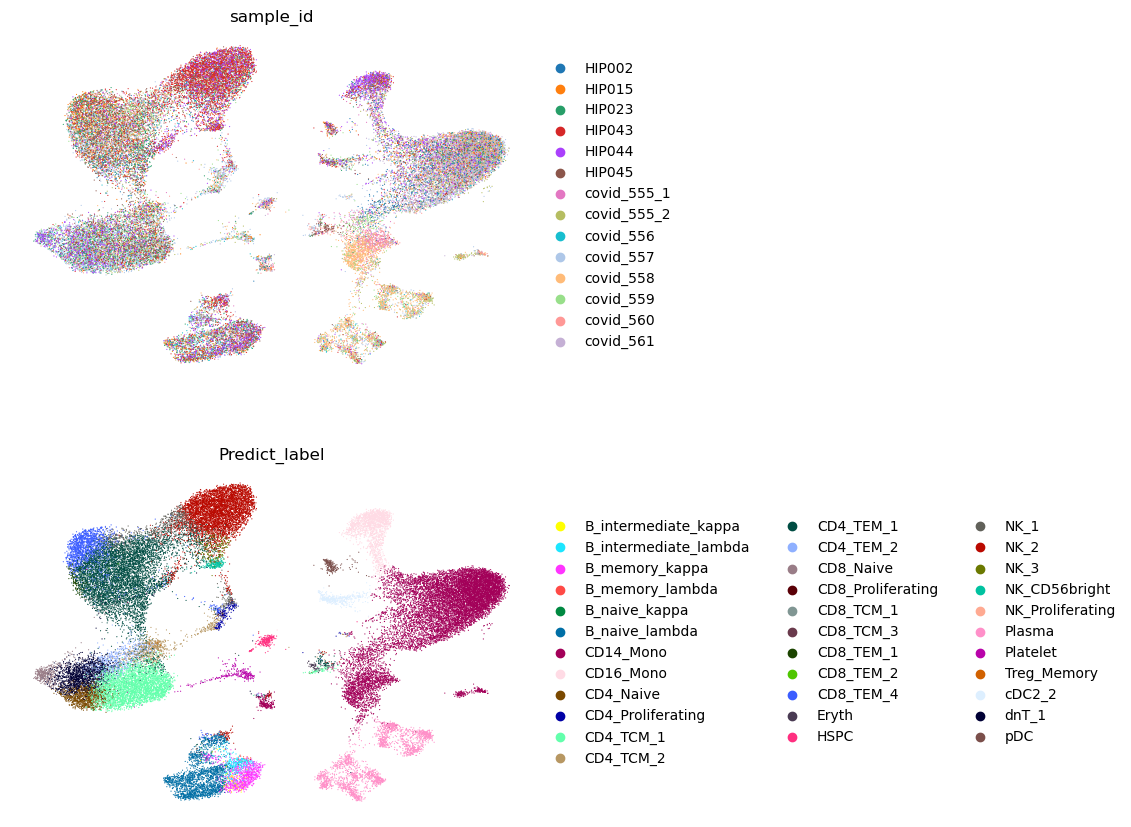

In [7]:
multi_resolution_cluster(adata, resolution1 = 0.5, method = 'Louvain')
VAE,C = train_integration_model(adata, batch_key = 'sample_id', z_dim=50, epochs = 150, warmup_epoch = 50)
obtain_embeddings(adata, VAE, C, cell_types_markers = markers_PBMC_l3)
#sc.pp.neighbors(adata, use_rep="X_scCRAFT")
sc.tl.umap(adata, min_dist=0.5)
sc.pl.umap(adata, color=["sample_id", "Predict_label"], frameon=False, ncols=1)

In [8]:
adata

AnnData object with n_obs × n_vars = 43767 × 2000
    obs: 'sample_id', 'subject_id', 'arm', 'timepoint', 'species', 'tissue', 'age', 'biological_sex', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'study', 'study_concat', 'n_counts', 'marker_label', 'ASDC_mDC_U_score', 'ASDC_pDC_U_score', 'B_intermediate_kappa_U_score', 'B_intermediate_lambda_U_score', 'B_memory_kappa_U_score', 'B_memory_lambda_U_score', 'B_naive_kappa_U_score', 'B_naive_lambda_U_score', 'CD14_Mono_U_score', 'CD16_Mono_U_score', 'CD8_Naive_U_score', 'CD4_Naive_U_score', 'CD4_Proliferating_U_score', 'CD4_TCM_1_U_score', 'CD4_TCM_2_U_score', 'CD4_TCM_3_U_score', 'CD4_TEM_1_U_score', 'CD4_TEM_2_U_score', 'CD4_TEM_3_U_score', 'CD4_TEM_4_U_score', 'CD8_Naive_2_U_score', 'CD8_Proliferating_U_score', 'CD8_TCM_1_U_score', 'CD8_TCM_2_U_score', 'CD8_TCM_3_U_score', 'CD8_TEM_1_U_score', 'CD8_TEM_2_U_score', 'CD8_TEM_3_U_score', 'CD8_TEM_4_U_score', 'CD8_TEM_5_U_score', 'CD8_TEM_6_U_score', '

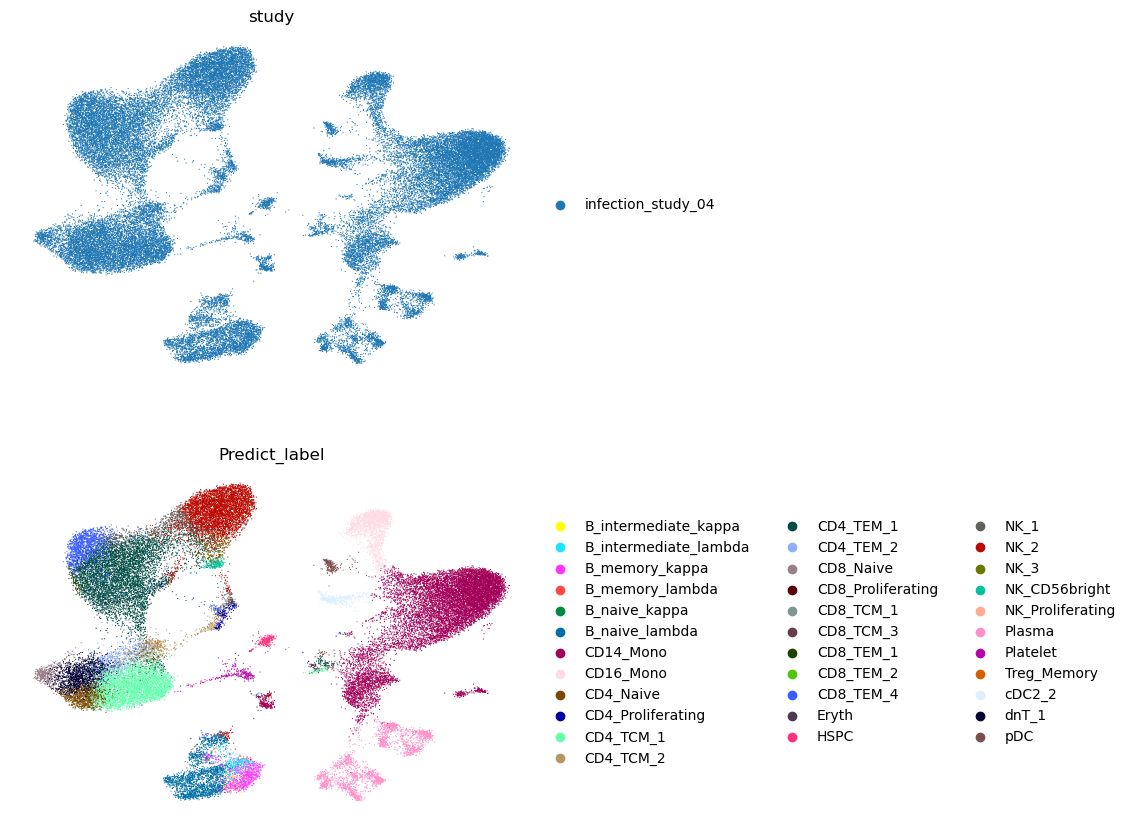

In [9]:
sc.pl.umap(adata, color=["study", "Predict_label"], frameon=False, ncols=1)

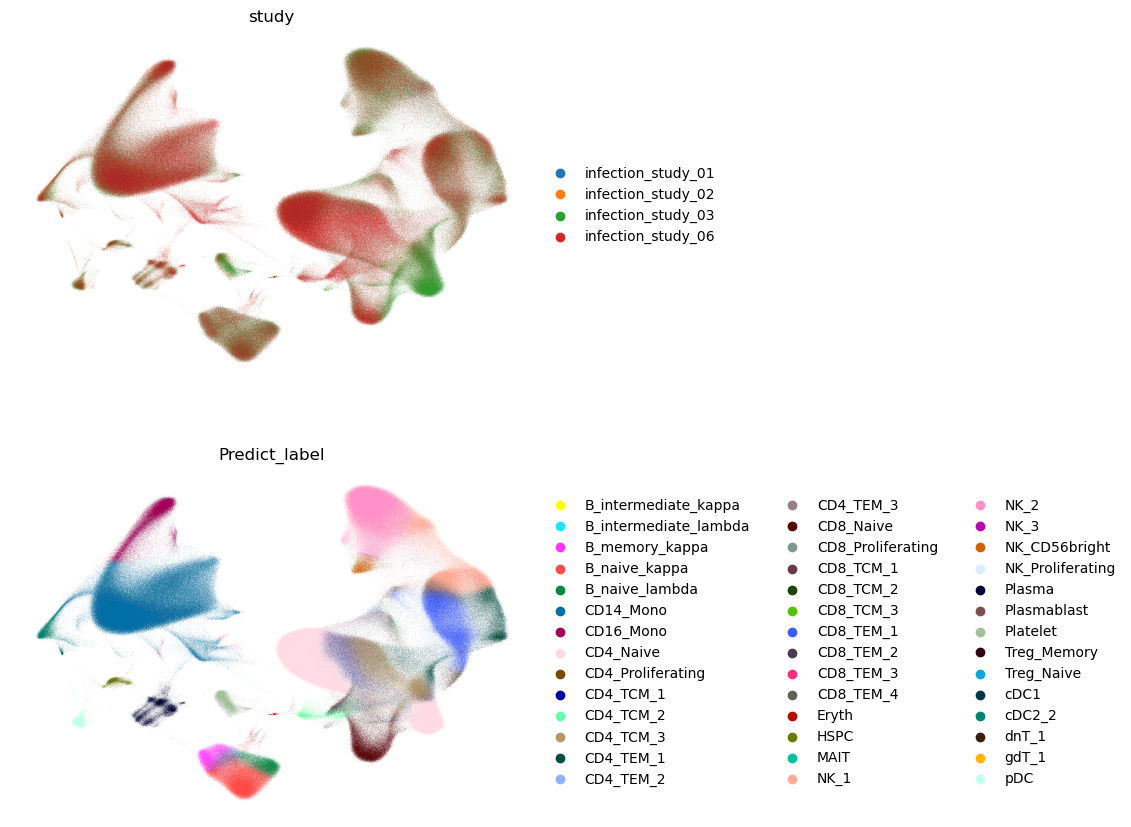

In [12]:
sc.pl.umap(adata, color=["study", "Predict_label"], frameon=False, ncols=1)

In [17]:
adata.obs["age"] = adata.obs["age"].astype(str)

adata.write_h5ad(
    "/nfs/roberts/project/pi_lg689/ch2343/Annotation_challenge_data/infection_filter_scCRAFT.h5ad"
)

In [10]:
# --------------------------------------------------
# Manual mapping from Predict_label to ontology cell_type
# --------------------------------------------------

predict_to_celltype = {
    # -------------------------
    # B cells
    # -------------------------
    "B_naive_kappa": "Naive B Cell",
    "B_naive_lambda": "Naive B Cell",

    "B_memory_kappa": "Memory B Cell",
    "B_memory_lambda": "Memory B Cell",
    "B_intermediate_kappa": "Memory B Cell",
    "B_intermediate_lambda": "Memory B Cell",

    "Plasma": "Plasma Cell",
    "Plasmablast": "Plasmablast",

    # -------------------------
    # Monocytes
    # -------------------------
    "CD14_Mono": "Classical Monocyte",
    "CD16_Mono": "Non-Classical Monocyte",

    # -------------------------
    # CD4 T cells
    # -------------------------
    "CD4_Naive": "CD4 Naive / T Central Memory",
    "CD4_TCM_1": "CD4 Naive / T Central Memory",
    "CD4_TCM_2": "CD4 Naive / T Central Memory",
    "CD4_TCM_3": "CD4 Naive / T Central Memory",

    "CD4_TEM_1": "CD4 T Effector Memory",
    "CD4_TEM_2": "CD4 T Effector Memory",
    "CD4_TEM_3": "CD4 T Effector Memory",
    "CD4_TEM_4": "CD4 T Effector Memory",

    "CD4_Proliferating": "CD4 T Cell (ab)",

    # -------------------------
    # CD8 T cells
    # -------------------------
    "CD8_Naive": "CD8 Naive / T Central Memory",
    "CD8_Naive_2": "CD8 Naive / T Central Memory",
    "CD8_TCM_1": "CD8 Naive / T Central Memory",
    "CD8_TCM_2": "CD8 Naive / T Central Memory",
    "CD8_TCM_3": "CD8 Naive / T Central Memory",

    "CD8_TEM_1": "CD8 Cytotoxic / T Effector Memory",
    "CD8_TEM_2": "CD8 Cytotoxic / T Effector Memory",
    "CD8_TEM_3": "CD8 Cytotoxic / T Effector Memory",
    "CD8_TEM_4": "CD8 Cytotoxic / T Effector Memory",
    "CD8_TEM_5": "CD8 Cytotoxic / T Effector Memory",
    "CD8_TEM_6": "CD8 Cytotoxic / T Effector Memory",

    "CD8_Proliferating": "CD8 T Cell (ab)",

    # -------------------------
    # Regulatory T cells
    # -------------------------
    "Treg_Naive": "Treg",
    "Treg_Memory": "Treg",

    # -------------------------
    # Gamma-delta T cells
    # -------------------------
    "gdT_1": "gdT Cell",
    "gdT_2": "gdT Cell",
    "gdT_3": "gdT Cell",
    "gdT_4": "gdT Cell",

    # -------------------------
    # MAIT / double-negative T / ILC-like T
    # -------------------------
    "MAIT": "MAIT Cell",

    # dnT is not explicitly present as a leaf in the ontology tree.
    # I map it to the broader T Cell node.
    "dnT_1": "T Cell",
    "dnT_2": "T Cell",

    # ILC is present in the prediction labels but not in the provided ontology tree.
    # I map it to the broader Lymphoid Cell node.
    "ILC": "Lymphoid Cell",

    # -------------------------
    # NK cells
    # -------------------------
    "NK_1": "NK Cell",
    "NK_2": "NK Cell",
    "NK_3": "NK Cell",
    "NK_4": "NK Cell",
    "NK_CD56bright": "NK Cell",
    "NK_Proliferating": "NK Cell",

    # -------------------------
    # Dendritic cells
    # -------------------------
    "pDC": "Plasmacytoid DC",
    "ASDC_pDC": "Plasmacytoid DC",
    "ASDC_mDC": "Plasmacytoid DC",  # ambiguous ASDC; use pDC-like ontology node unless you prefer DC

    "cDC1": "Conventional DC 1",
    "cDC2_1": "Conventional DC 2",
    "cDC2_2": "Conventional DC 2",

    # -------------------------
    # Other blood cells
    # -------------------------
    "Eryth": "RBC",
    "Platelet": "Platelet",
    "HSPC": "HSC",
}

# --------------------------------------------------
# Apply mapping
# --------------------------------------------------

adata.obs["cell_type"] = adata.obs["Predict_label"].map(predict_to_celltype)

# --------------------------------------------------
# Check unmapped labels
# --------------------------------------------------

unmapped = sorted(
    adata.obs.loc[adata.obs["cell_type"].isna(), "Predict_label"]
    .dropna()
    .unique()
)

print("Number of unmapped Predict_label values:", len(unmapped))
print("Unmapped labels:")
print(unmapped)

# Optional: keep original label as backup
adata.obs["Predict_label_original"] = adata.obs["Predict_label"].astype(str)

# Optional: convert to category
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Check mapping result
print(adata.obs[["Predict_label", "cell_type"]].drop_duplicates().sort_values("Predict_label"))
print(adata.obs["cell_type"].value_counts(dropna=False))

Number of unmapped Predict_label values: 0
Unmapped labels:
[]
                                             Predict_label  \
infection_study_04_covid_555_1.224    B_intermediate_kappa   
infection_study_04_covid_555_1.72    B_intermediate_lambda   
infection_study_04_covid_555_1.59           B_memory_kappa   
infection_study_04_covid_555_1.471         B_memory_lambda   
infection_study_04_HIP023.3004               B_naive_kappa   
infection_study_04_covid_555_1.81           B_naive_lambda   
infection_study_04_covid_555_1.15                CD14_Mono   
infection_study_04_covid_555_1.191               CD16_Mono   
infection_study_04_covid_555_1.404               CD4_Naive   
infection_study_04_covid_555_1.847       CD4_Proliferating   
infection_study_04_covid_555_1.32                CD4_TCM_1   
infection_study_04_covid_555_1.78                CD4_TCM_2   
infection_study_04_covid_555_1.16                CD4_TEM_1   
infection_study_04_covid_555_1.47                CD4_TEM_2   
infecti

In [11]:
import os
import pandas as pd

out_dir = "/nfs/roberts/project/pi_lg689/ch2343/Annotation_challenge_data/results"
os.makedirs(out_dir, exist_ok=True)

if "study" not in adata.obs.columns:
    raise ValueError("adata.obs must contain a 'study' column.")

if "cell_type" not in adata.obs.columns:
    raise ValueError("adata.obs must contain the mapped 'cell_type' column.")

for study_name in sorted(adata.obs["study"].dropna().unique()):
    print(f"Processing {study_name}")

    obs_sub = adata.obs.loc[adata.obs["study"] == study_name].copy()

    # Remove study prefix from obs_names
    # Example:
    # infection_study_01_AAACCCAAGGGCAATC-1 -> AAACCCAAGGGCAATC-1
    prefix = f"{study_name}_"
    cell_ids = obs_sub.index.astype(str)

    clean_cell_ids = [
        x.replace(prefix, "", 1) if x.startswith(prefix) else x
        for x in cell_ids
    ]

    # Save only one annotation column: cell_type
    anno_df = pd.DataFrame(
        {
            "cell_type": obs_sub["cell_type"].astype(str).values
        },
        index=clean_cell_ids
    )

    # Optional: name the index if needed
    anno_df.index.name = None

    out_path = os.path.join(out_dir, f"{study_name}_annotation.csv")
    anno_df.to_csv(out_path)

    print(f"Saved: {out_path}")
    print(f"Shape: {anno_df.shape}")
    print("-" * 80)

Processing infection_study_04
Saved: /nfs/roberts/project/pi_lg689/ch2343/Annotation_challenge_data/results/infection_study_04_annotation.csv
Shape: (43767, 1)
--------------------------------------------------------------------------------
